In [21]:
import pandas as pd
import numpy as np
import glob
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [28]:
# Load data from multiple years
def load_voting_data(path_pattern):
    files = glob.glob(path_pattern)
    df_list = [pd.read_csv(f, delimiter=';', quotechar='"') for f in files]
    return pd.concat(df_list, ignore_index=True)

# Define the path pattern
path_pattern = "../data/voting/votes/votacoesVotos-*.csv"

df = load_voting_data(path_pattern)

In [32]:
# Standardize votes (consider only 'Yes' and 'No', others as 'Other')
vote_mapping = {
    'sim': 'Yes', 'não': 'No', 'nao': 'No'
}
df['voto'] = df['voto'].str.strip().str.lower().map(vote_mapping).fillna('Other')
print("Vote standardization completed. Unique votes:", df['voto'].unique())

# Sort by voting session chronological order
df = df.sort_values(by='idVotacao')
print("Data sorted by voting session.")

# Create an empty dataframe to store clusters
df_clusters_list = []

# Iterate over voting sessions to ensure clustering only uses past data
unique_sessions = df['idVotacao'].unique()
for i, current_session in enumerate(unique_sessions):
    past_sessions = unique_sessions[:i]  # Only use past sessions
    if len(past_sessions) < 2:
        print(f"Skipping session {current_session} due to insufficient past data.")
        continue  # Skip first and second sessions to avoid clustering issues
    
    past_votes = df[df['idVotacao'].isin(past_sessions)]
    vote_pivot = past_votes.pivot_table(index='idVotacao', columns='voto', aggfunc='size', fill_value=0)
    
    # Normalize vote data
    scaler = StandardScaler()
    vote_matrix = scaler.fit_transform(vote_pivot)
    print(f"Processing session {i+1}/{len(unique_sessions)}: {current_session}. Data shape: {vote_matrix.shape}")
    
    # Determine the optimal number of clusters using the silhouette method
    silhouette_scores = []
    range_n_clusters = range(2, min(11, len(past_sessions)))  # Ensure we have enough samples for clustering

    for num_clusters in range_n_clusters:
        if len(vote_matrix) < num_clusters:
            break  # Avoid clustering when not enough samples are available
        kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init='auto')
        cluster_labels = kmeans.fit_predict(vote_matrix)
        silhouette_avg = silhouette_score(vote_matrix, cluster_labels)
        silhouette_scores.append(silhouette_avg)
    
    if not silhouette_scores:
        print(f"Skipping session {current_session} due to lack of valid clustering options.")
        continue
    
    # Select the optimal number of clusters
    optimal_clusters = range_n_clusters[np.argmax(silhouette_scores)]
    print(f"Optimal number of clusters for session {current_session}: {optimal_clusters}")
    
    # Apply K-Means clustering with optimal clusters
    kmeans = KMeans(n_clusters=optimal_clusters, random_state=42, n_init='auto')
    kmeans.fit(vote_matrix)
    
    # Assign cluster label for the current session
    current_cluster = kmeans.predict(scaler.transform(df[df['idVotacao'] == current_session]
                                                      .pivot_table(index='idVotacao', columns='voto', aggfunc='size', fill_value=0)))[0]
    print(f"Assigned cluster for session {current_session}: {current_cluster}")
    
    df_clusters_list.append({'idVotacao': current_session, 'Cluster': current_cluster})

# Create final cluster dataframe
df_clusters = pd.DataFrame(df_clusters_list)
print("Clustering completed. Shape:", df_clusters.shape)

Vote standardization completed. Unique votes: ['Other']
Data sorted by voting session.
Skipping session 101666-71 due to insufficient past data.
Skipping session 104342-141 due to insufficient past data.
Processing session 3/5348: 104342-99. Data shape: (2, 1)
Skipping session 104342-99 due to lack of valid clustering options.
Processing session 4/5348: 104485-117. Data shape: (3, 1)
Optimal number of clusters for session 104485-117: 2
Assigned cluster for session 104485-117: 1
Processing session 5/5348: 104509-28. Data shape: (4, 1)
Optimal number of clusters for session 104509-28: 2
Assigned cluster for session 104509-28: 1
Processing session 6/5348: 104731-67. Data shape: (5, 1)
Optimal number of clusters for session 104731-67: 2
Assigned cluster for session 104731-67: 1
Processing session 7/5348: 1049075-6. Data shape: (6, 1)
Optimal number of clusters for session 1049075-6: 2
Assigned cluster for session 1049075-6: 0
Processing session 8/5348: 1049167-8. Data shape: (7, 1)
Optimal

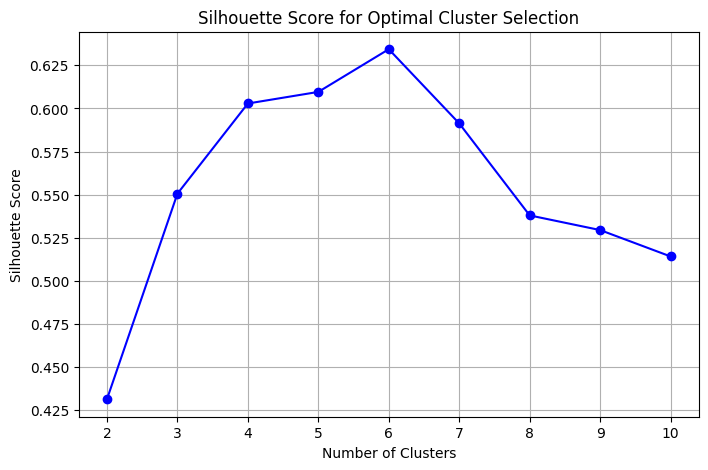

In [24]:
# Plot silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal Cluster Selection')
plt.grid(True)
plt.show()

In [25]:
# Select the optimal number of clusters
optimal_clusters = range_n_clusters[np.argmax(silhouette_scores)]
optimal_clusters

6

In [26]:
# Apply K-Means clustering with optimal clusters
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
kmeans.fit(vote_matrix)

# Assign cluster labels
df_clusters = pd.DataFrame({'idVotacao': vote_pivot.index, 'Cluster': kmeans.labels_})
df_clusters

e:\Anaconda\envs\dados_abertos\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,idVotacao,Cluster
0,101666-71,1
1,104342-141,1
2,104342-99,3
3,104485-117,2
4,104509-28,2
...,...,...
5343,996553-34,3
5344,996553-39,3
5345,996553-43,1
5346,996882-4,2


In [27]:
df_clusters.to_csv('df_clusters.csv', index=False, encoding='utf-8')